# PCA (Principal Component Analysis)

In [33]:
import pandas as pd

# Load the Wine dataset
df_wine = pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')

# Show a data sample
print(f"Sample:\n", df_wine.sample(10))

# Show some general statistics
print(f"\n\nDescription:\n", df_wine.describe())

Sample:
      Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
144     3    12.25        3.88  2.20  18.5  112     1.38        0.78   
88      2    11.64        2.06  2.46  21.6   84     1.95        1.69   
44      1    13.05        1.77  2.10  17.0  107     3.00        3.00   
167     3    12.82        3.37  2.30  19.5   88     1.48        0.66   
57      1    13.29        1.97  2.68  16.8  102     3.00        3.23   
166     3    13.45        3.70  2.60  23.0  111     1.70        0.92   
154     3    12.58        1.29  2.10  20.0  103     1.48        0.58   
116     2    11.82        1.47  1.99  20.8   86     1.98        1.60   
49      1    13.94        1.73  2.27  17.4  108     2.88        3.54   
173     3    13.71        5.65  2.45  20.5   95     1.68        0.61   

     Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
144                  0.29     1.14       8.21  0.65  2.00      855  
88                   0.48     1.35       2.80  1.00  2.75   

Steps: 
1. **Data standarization:** all the variables will have a mean 0 and std = 1 to prevent variables to dominate others just bc they have bigger values
2. **Calculate the covariance matrixes:** this tells us how variables are correlated (ej: if alcohol and color have positive covariance, when one increases, the other will also increase)
3. **Find the eigenvalues and eigenvectors:** 
    - The eigenvalues indicate how much information (variance) each principal component carries. 
    - The eigenvectors give you the direction of these components.
4. **Order and select the best components:** You typically choose the first 2 or 3, which explain most of the variance. This allows you to visualize data that was in 13 dimensions in just 2D.

**Data standardization**

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Split the dataset into features (X) and target labels (y).
# y: The first column (Wine) contains wine class types labels (1, 2, 3).
# X: All other columns (Alcohol, Malic.acid, etc.) are features for PCA
# * Why this? PCA is applied to features, not the target variable. This ensures we reduce the dimensionality of the input data, not the labels.
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

**Covariance matrix**

In [ ]:
# Covariance Matrix: Computes relationships between features. PCA uses this to find directions (principal components) of maximum variance.
cov_mat = np.cov(X_train_std.T)

**Compute the eigenvalues and eigenvectors**

In [ ]:
# Eigenvalues: Represent the "importance" of each principal component (larger eigenvalue = more variance explained).
# Eigenvectors: Define the directions of the principal components (orthogonal axes in the new feature space).
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

print('\nEigenvalues \n%s' % eigen_vals)
print('\nEigenvectors \n%s' % eigen_vecs)


Eigenvalues 
[4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]

Eigenvectors 
[[-1.37242175e-01  5.03034778e-01 -1.37748734e-01 -3.29610003e-03
   2.90625226e-01 -2.99096847e-01 -7.90529293e-02  3.68176414e-01
   3.98377017e-01 -9.44869777e-02  3.74638877e-01 -1.27834515e-01
   2.62834263e-01]
 [ 2.47243265e-01  1.64871190e-01  9.61503863e-02  5.62646692e-01
  -8.95378697e-02 -6.27036396e-01  2.74002014e-01  1.25775752e-02
  -1.10458230e-01  2.63652406e-02 -1.37405597e-01  8.06401578e-02
  -2.66769211e-01]
 [-2.54515927e-02  2.44564761e-01  6.77775667e-01 -1.08977111e-01
   1.60834991e-01 -3.89128239e-04 -1.32328045e-01 -1.77578177e-01
  -3.82496856e-01  1.42747511e-01  4.61583035e-01  1.67924873e-02
  -1.15542548e-01]
 [ 2.06945084e-01 -1.13529045e-01  6.25040550e-01  3.38187002e-02
  -5.15873402e-02  4.05836452e-02 -2.23999097e-01  4.40592110e-01
   2.43373853e-01 -1.30485780e-01 -4.18953

**Sort eigenvalues and eigenvectors**

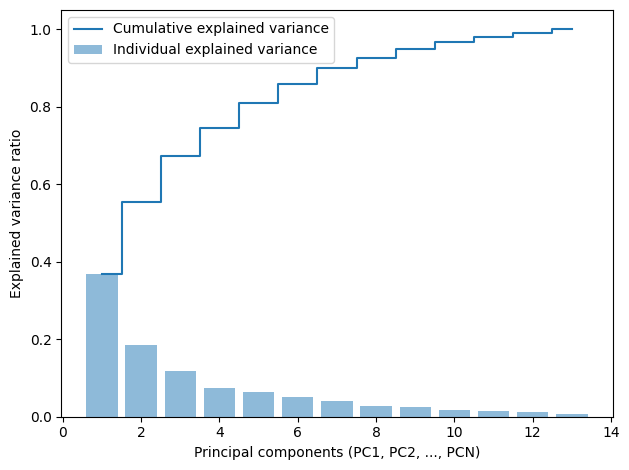

In [21]:
# Sort eigenvalues and eigenvectors
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in eigen_vals]
cum_var_exp = np.cumsum(var_exp)

# Visualization of the variance
import matplotlib.pyplot as plt

plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_var_exp)+1), cum_var_exp, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components (PC1, PC2, ..., PCN)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

☝️ Interpretation of the chart above: we can see that the 3 first components represent about 80% of the variance. This means we can represent the data in just that number of dimensions without loosing too much information. The line represents the cummulative variance.

\* *In case we needed 5 or 6 components to reach that 80%, is probably not worth it using this reduction system*

**Eigenvector selection**

In [ ]:
# Let's perform a stacking of the eigenvectors corresponding to the first two eigenvalues
# This code picks first 2 eigenvectors (PC1 and PC2)
W = np.hstack((eigen_vecs[:, [0]].reshape(-1,1), eigen_vecs[:, [1]].reshape(-1,1)))

# Data projection (13x2 dimensions to 2D PCA space)
X_train_pca = X_train_std @ W
X_test_pca = X_test_std @ W

**Visualization**

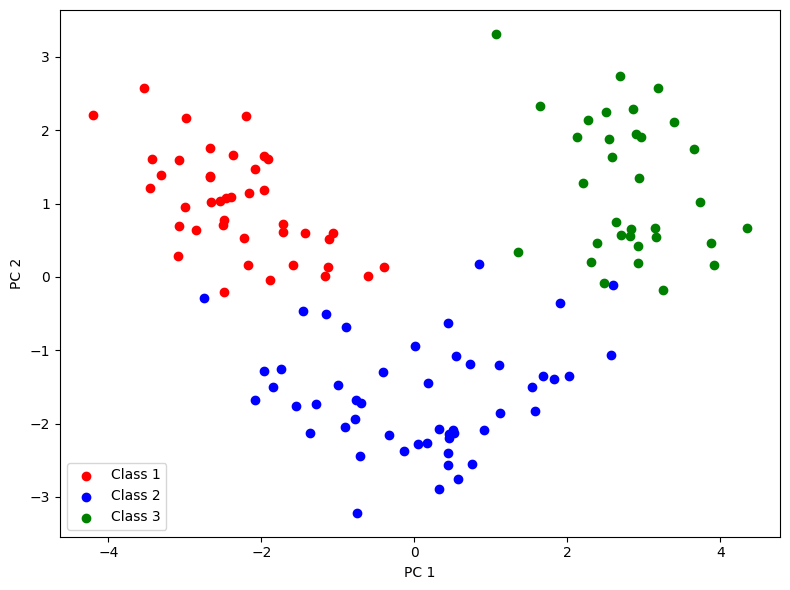

In [19]:
# Let's plot the projected 2D training set
plt.figure(figsize=(8, 6))
for l, c in zip(np.unique(y_train), ('r', 'b', 'g')):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                label=f'Class {l}',
                c=c)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


☝️ Interpretation of the chart above: 
    - The 3 colors correspond to wine classes (1-red, 2-blue, 3-green) from the original "Wine" column
    - This shows how well the PCA-separated the different wine types in 2D space
    - We observe that original features strongly correlate with class differences.